# Zebra finch call detection — September update

Three results, one clarification, and a change you should make to the pipeline today.

**TL;DR**

1. **Onsets are currently ~10 ms late, systematically.** A one-line fix removes it and cuts timing
   error by a third. It costs nothing.
2. **Pretraining is doing the work, not the architecture.** An untrained network of identical
   shape scores 0.75 where ours scores 0.95.
3. **Don't chop audio into short clips before feeding the model.** Run it over the recording and
   group afterwards. Below 125 ms, chopping costs real accuracy.
4. **Clarification:** our headline 0.95 answers *"is there a call somewhere in this second"*, not
   *"is this exact instant a call"*. The second question scores 0.77.

In [1]:
from pathlib import Path
import json
from IPython.display import Image, display

ANA = Path.home() / "zf_labelset/zf_detection_dataset_v1/analysis"
VIZ = ANA / "viz"
load = lambda n: json.loads((ANA / n).read_text())

SB  = load("subframe_onset.json")      # onset timing
RS  = load("resolution_sweep.json")    # segment length
FB  = load("frame_baselines.json")     # frame-level baselines
CTL = load("randinit_control.json")    # the untrained-network control
print("loaded 4 result files")

loaded 4 result files


## 1. Onsets are ~10 ms late, and the fix is free

The model reports one answer every 20 ms. To say where a call starts, we threshold its confidence
curve and take the first tick above the line. That rule always rounds **up** to the next tick, so
every onset comes out late — by half a tick on average.

Instead, read *between* the two ticks: if confidence was 0.15 at one tick and 0.75 at the next,
the 0.4 threshold was crossed about 40% of the way across. Same arithmetic as "it was 15° at noon
and 21° at 2pm, so it hit 18° around 1pm."

In [2]:
a = SB["arms"]
rows = [("first tick above threshold (current)", "coarse_nearest", "1x"),
        ("read between ticks  (proposed)",       "coarse_interp",  "1x"),
        ("run the model 4x on shifted audio",    f"shifted_K{SB['K']}_nearest", "4x")]
print(f"{'method':38s}{'onset error':>13s}{'how late':>11s}{'compute':>9s}")
print("-" * 71)
for label, key, cost in rows:
    r = a[key]
    print(f"{label:38s}{r['med_abs_err_ms']:10.1f} ms{r['bias_ms']:+9.1f} ms{cost:>9s}")
print("\n'how late' is a systematic bias: every onset we have published is shifted by it.")
print("Reading between ticks removes the bias AND matches 4x the compute, for free.")

method                                  onset error   how late  compute
-----------------------------------------------------------------------
first tick above threshold (current)        13.3 ms    +10.6 ms       1x
read between ticks  (proposed)               8.8 ms     +1.7 ms       1x
run the model 4x on shifted audio            8.6 ms     +5.1 ms       4x

'how late' is a systematic bias: every onset we have published is shifted by it.
Reading between ticks removes the bias AND matches 4x the compute, for free.


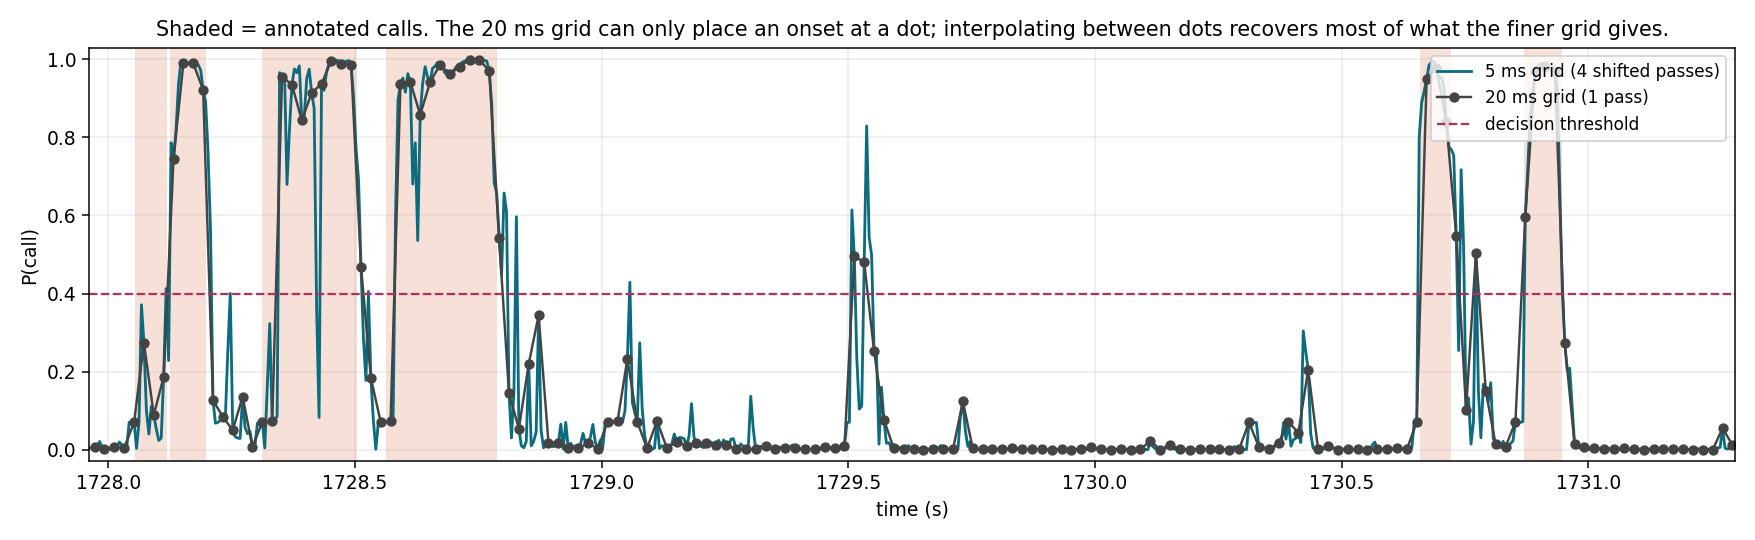

In [3]:
display(Image(str(VIZ / "10_probability_curve.png")))

Shaded bands are real calls. The dark dots are the model's 20 ms answers; the teal line is what
you get from running it four times on shifted audio. **Reading between the dark dots recovers
almost all of what the teal line gives you.**

This also stops improving at about 8 ms no matter what we do — that floor is the model's own
temporal blur (it sees 25 ms of audio at once), not the sampling rate. Getting below it needs
retraining, not better post-processing.

## 2. Pretraining is what's working — not just "a neural net"

The worry: any deep network, even an untrained one, is a complicated nonlinear function and might
score well by accident. So we ran the identical architecture with **random weights** and with the
**trained weights scrambled in place**, on identical data and folds.

In [4]:
t = CTL["layer_table"]
best = max(t, key=lambda k: t[k]["pretrained"])
print(f"{'model':36s}{'AUC':>8s}")
print("-" * 44)
print(f"{'ours (run11, pretrained)':36s}{t[best]['pretrained']:8.3f}")
print(f"{'log-mel spectrogram baseline':36s}{CTL['baselines']['logmel']:8.3f}")
print(f"{'same network, random weights':36s}{t[best]['rand_mean']:8.3f}")
print(f"{'same network, weights scrambled':36s}{t[best]['shuf_mean']:8.3f}")
print(f"{'loudness alone':36s}{CTL['baselines']['logenergy']:8.3f}")
b = CTL["bootstrap"]["rand_seed0"]["layer_matched"]
print(f"\ntrained minus untrained: {b['delta']:+.3f}  "
      f"[{b['lo']:+.3f}, {b['hi']:+.3f}]  -- interval clear of zero")
print("\nNote the untrained network still reaches ~0.75, well above loudness (0.51).")
print("Quoted on its own that would look like a result. It is why this control was needed.")

model                                    AUC
--------------------------------------------
ours (run11, pretrained)               0.957
log-mel spectrogram baseline           0.900
same network, random weights           0.750
same network, weights scrambled        0.701
loudness alone                         0.509

trained minus untrained: +0.194  [+0.166, +0.223]  -- interval clear of zero

Note the untrained network still reaches ~0.75, well above loudness (0.51).
Quoted on its own that would look like a result. It is why this control was needed.


An extra finding worth knowing: **most of the learning sits in the convolutional front end**, not
the transformer. The trained front end alone reaches 0.946; all twelve transformer blocks on top
of it add about +0.011.

## 3. Don't chop audio into clips before feeding the model

Two ways to run a detector over a recording:

- **Chop first** — cut the audio into pieces, hand each piece over alone.
- **Run continuously** — feed the whole recording, then group the results into pieces afterwards.

The model works by letting each moment look at the moments around it. A 40 ms clip handed over
alone gives it two data points and nothing to compare them to.

In [5]:
sizes = sorted([int(k[1:]) for k in RS if k.startswith("w")], reverse=True)
print(f"{'segment':>9s}{'chop first':>13s}{'continuous':>13s}{'difference':>13s}")
print("-" * 48)
for s in sizes:
    r = RS[f"w{s}"]["center"]
    bw = max(r["windowed_L0"], r["windowed_L6"])
    bc = max(r["continuous_L0"], r["continuous_L6"])
    d = bc - bw
    flag = "  tie" if abs(d) < 0.01 else ("  <- context wins" if d > 0 else "  <- chopping wins")
    print(f"{s:7d}ms{bw:13.3f}{bc:13.3f}{bc-bw:+13.3f}{flag}")
print("\nCrossover at ~125 ms. Longer than that, a focused clip is better; shorter, context wins.")

  segment   chop first   continuous   difference
------------------------------------------------
   1000ms        0.767        0.673       -0.094  <- chopping wins
    500ms        0.891        0.813       -0.079  <- chopping wins
    250ms        0.946        0.907       -0.039  <- chopping wins
    125ms        0.951        0.949       -0.002  tie
     80ms        0.925        0.944       +0.019  <- context wins
     40ms        0.903        0.926       +0.023  <- context wins

Crossover at ~125 ms. Longer than that, a focused clip is better; shorter, context wins.


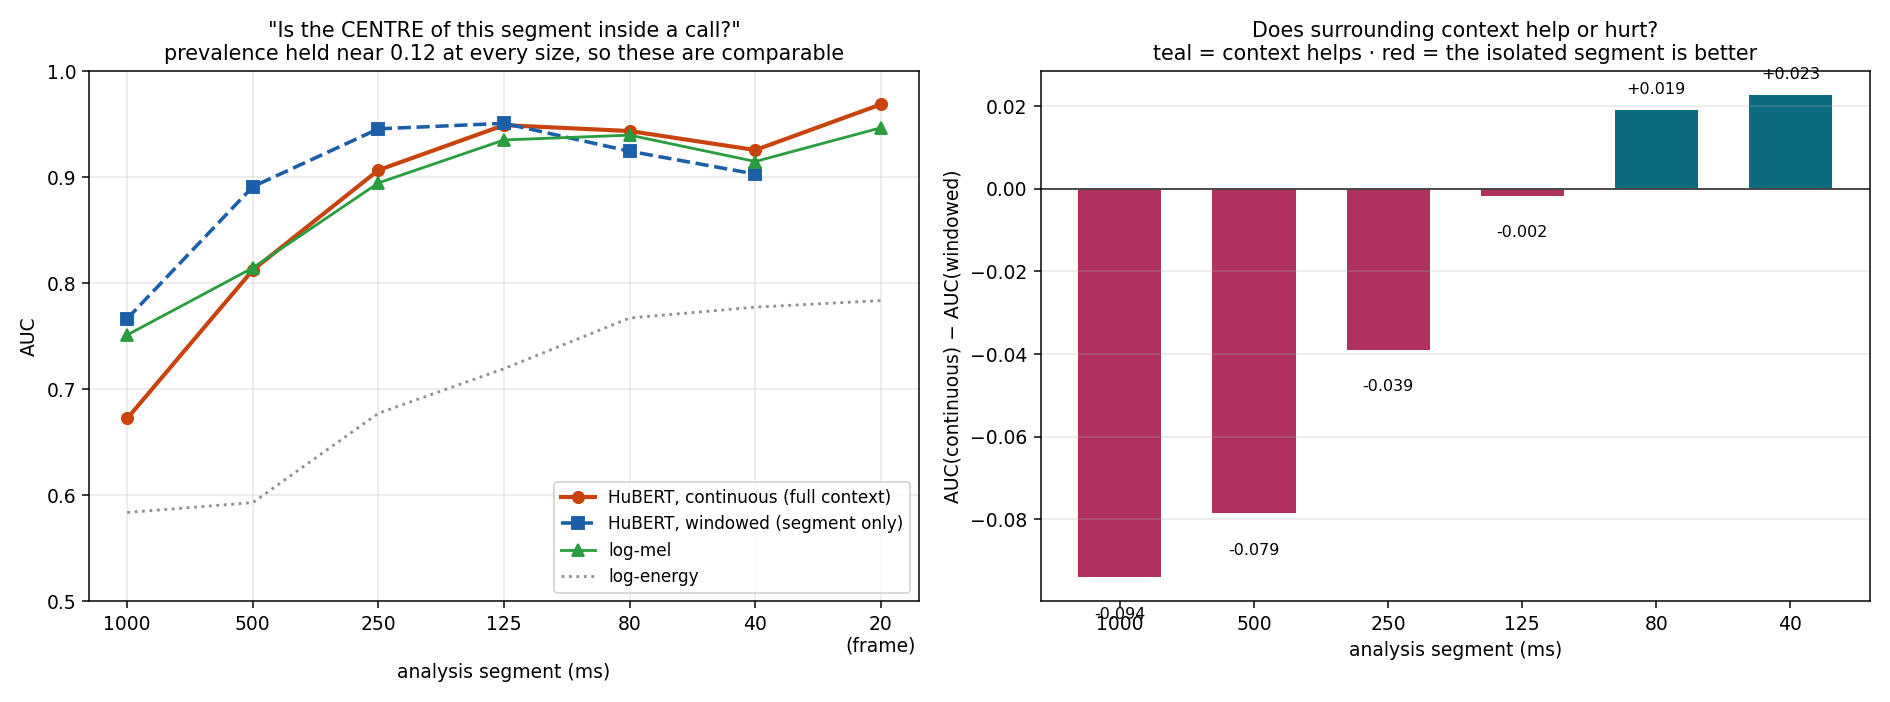

In [6]:
display(Image(str(VIZ / "08_resolution_sweep.png")))

The left panel also shows accuracy flattening below ~125 ms. **Sampling finer buys timing
precision, not detection accuracy.**

And the green line is worth being honest about: a plain spectrogram baseline is close to us on
*localising* calls. Our advantage is in *detecting* them — at the frame level the ranking gap is
modest but the precision gap is not.

In [7]:
f = FB["full"]
print(f"{'frame-level (20 ms)':28s}{'AUC':>8s}{'AP':>8s}")
print("-" * 44)
print(f"{'HuBERT (ours)':28s}{f['hubert_L0']['auc']:8.3f}{f['hubert_L0']['ap']:8.3f}")
print(f"{'log-mel spectrogram':28s}{f['logmel_100ms']['auc']:8.3f}{f['logmel_100ms']['ap']:8.3f}")
print(f"{'loudness alone':28s}{f['logenergy']['auc']:8.3f}{f['logenergy']['ap']:8.3f}")
print(f"\nAP is the number that matters here -- only {FB['prevalence']*100:.0f}% of frames contain a call,")
print(f"and AP is sensitive to that. Our margin over the spectrogram baseline is")
print(f"{FB['hubert_minus_mel100_auc']:+.3f} on AUC but {FB['hubert_minus_mel100_ap']:+.3f} on AP.")

frame-level (20 ms)              AUC      AP
--------------------------------------------
HuBERT (ours)                  0.969   0.868
log-mel spectrogram            0.947   0.800
loudness alone                 0.784   0.278

AP is the number that matters here -- only 12% of frames contain a call,
and AP is sensitive to that. Our margin over the spectrogram baseline is
+0.022 on AUC but +0.068 on AP.


## 4. What our headline number actually measures

Same model, same second of audio, two different questions:

In [8]:
r = RS["w1000"]
print(f"{'question asked of a 1-second window':44s}{'ours':>8s}{'spectrogram':>14s}")
print("-" * 66)
print(f"{'is there a call SOMEWHERE in this second':44s}"
      f"{max(r['overlap']['windowed_L0'], r['overlap']['windowed_L6']):8.3f}"
      f"{r['overlap']['logmel']:14.3f}")
print(f"{'is this exact instant inside a call':44s}"
      f"{max(r['center']['windowed_L0'], r['center']['windowed_L6']):8.3f}"
      f"{r['center']['logmel']:14.3f}")
print("\nA 1-second window holds ~1.5 calls somewhere, so presence is nearly free.")
print("Worth stating which question a number answers whenever we report one.")

question asked of a 1-second window             ours   spectrogram
------------------------------------------------------------------
is there a call SOMEWHERE in this second       0.951         0.900
is this exact instant inside a call            0.767         0.751

A 1-second window holds ~1.5 calls somewhere, so presence is nearly free.
Worth stating which question a number answers whenever we report one.


## Recommendations

| | change | effort | payoff |
|---|---|---|---|
| 1 | Read onsets *between* ticks instead of snapping to the next one | one function | 34% lower timing error, removes a ~10 ms bias |
| 2 | Run the model over whole recordings, group afterwards | pipeline change | up to +0.05 on short segments |
| 3 | Use layer 0 | config | best at detection *and* timing, and cheapest |
| 4 | Stop sampling finer than 20 ms | — | no gain available there |
| 5 | Say which question each number answers | writing | avoids a 0.18 misreading |

**Where the next real gain is:** post-processing is now exhausted at ~8 ms timing error. Beating
it means changing the model — a shorter convolutional stride, or fine-tuning with an objective
that rewards sharp call boundaries. That needs training, not decoding.

## Details

- Deep dive with every figure and interactive cells: `ZF_embeddings_and_controls.ipynb`
- Raw results: `analysis/subframe_onset.json`, `resolution_sweep.json`, `frame_baselines.json`,
  `randinit_control.json`, `onset_probe.json`
- Code: `zfeval/experiments/`

**Caveat on all of the above:** these come from 30 minutes of recording 111021-000, the one file
with exhaustive onset/offset annotation. Splits are contiguous time blocks within that recording,
so this is not a held-out-recording result. It tells us about method choices, not about how the
detector transfers to a new bird or a new room.